# Downloading Dataset

In [ ]:
!gdown 1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7

Downloading...
From (original): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7
From (redirected): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7&confirm=t&uuid=14140dc5-be73-4448-a27f-d4ff7c9b111d
To: /content/finetune_sharegpt.jsonl
100% 194M/194M [00:01<00:00, 115MB/s]


# Examples

In [ ]:
import os
import time
import json
from tqdm import tqdm


with open('finetune_sharegpt.jsonl') as f:
  data = [json.loads(sample) for sample in f.readlines()]

In [ ]:
data[0]

{'id': 'rice_blast_001',
 'crop': 'rice',
 'symptom_text': 'আমার ধানের পাতায় ছোট ছোট বাদামী রঙের দাগ দেখা যাচ্ছে। প্রথমে মনে হয়েছিল পোকা লেগেছে, কিন্তু দাগগুলো বাড়ছে।',
 'image_path': None,
 'disease_label': 'Rice Blast (ধানের ব্লাস্ট)',
 'qa_flow': [{'role': 'assistant',
   'content': 'আপনার ধানের পাতায় কী ধরনের দাগ দেখা যাচ্ছে? দাগগুলো কি চোখের মতো গোল, নাকি অন্য কোনো আকারের? এবং কি দাগগুলো পুরো পাতায় ছড়িয়ে পড়ছে?'},
  {'role': 'user',
   'content': 'দাগগুলো প্রথমে ছোট ছিল, এখন অনেকটা চোখের মতো দেখাচ্ছে। চারপাশে হালকা বাদামী আর ভেতরে ধূসর। পাতাগুলো ধীরে ধীরে শুকিয়ে যাচ্ছে।'},
  {'role': 'assistant',
   'content': 'আপনি কি গাছের কাণ্ড বা শীষেও কোনো দাগ বা পরিবর্তন লক্ষ্য করেছেন? যেমন, কাণ্ডের গিঁটে বা শীষের গোড়ায় কোনো দাগ?'},
  {'role': 'user',
   'content': 'হ্যাঁ, শীষের গোড়ায় একটু কালচে দেখাচ্ছে। মনে হচ্ছে শীষ বেরোনোর সময় ভেঙে যেতে পারে।'}],
 'advice': 'আপনার ধানের জমিতে ব্লাস্ট রোগ দেখা দিয়েছে। দ্রুত Tricyclazole বা Propiconazole স্প্রে করুন। ইউরিয়ার ব্যবহার কমিয়ে দিন এবং জমিতে সব

In [ ]:
def create_single_conversation(sample):

    single_sample = [{'role': 'user',
      'content': sample['symptom_text']
    }]

    for qa_entry in sample['qa_flow']:
      single_sample.append(qa_entry)

    single_sample.append({'role': 'assistant',
      'content': sample['advice'] + '\nNote: ' +  sample['notes']
    })

    return single_sample

In [ ]:
def fix_single_conversation(sample):
  merged = []
  last_role = None
  for s in sample:
    current_role = s['role']
    current_content = s['content']
    if last_role and last_role == current_role:
        merged[-1]['content'] += f'\n{current_content}'
    else:
        merged.append({'role': current_role, 'content': current_content})
        last_role = current_role
  return merged

# Data Structure

In [ ]:
dataset = []

for sample in tqdm(data):
  dataset.append(fix_single_conversation(create_single_conversation(sample)))

100%|██████████| 96311/96311 [00:00<00:00, 103073.68it/s]


In [ ]:
dataset[5]

[{'role': 'user',
  'content': 'ধানের পাতাগুলো দ্রুত হলুদ হয়ে যাচ্ছে এবং শুকিয়ে যাচ্ছে। মনে হচ্ছে যেন গাছ দুর্বল হয়ে পড়েছে।'},
 {'role': 'assistant',
  'content': 'পাতা হলুদ হওয়ার সাথে সাথে কি আপনি পাতায় কোনো ধরনের দাগ দেখতে পাচ্ছেন? যদি দেখেন, তাহলে দাগগুলো কেমন?'},
 {'role': 'user',
  'content': 'হ্যাঁ, পাতায় হালকা বাদামী রঙের ছোট ছোট দাগ দেখা যাচ্ছে। দাগগুলো প্রথমে ছোট ছিল, কিন্তু এখন বাড়ছে।'},
 {'role': 'assistant',
  'content': 'আপনি কি কাণ্ড বা কলার অংশে কোনো পরিবর্তন লক্ষ্য করেছেন? যেমন - কাণ্ড নরম হয়ে যাওয়া বা তাতে দাগ পড়া।'},
 {'role': 'user',
  'content': 'কাণ্ডটা একটু নরম মনে হচ্ছে, এবং সেখানেও হালকা বাদামী দাগ দেখা যাচ্ছে।'},
 {'role': 'assistant',
  'content': 'আপনার ধানের জমিতে শীথ ব্লাইট (Sheath Blight) রোগের লক্ষণ দেখা যাচ্ছে। এটি একটি গুরুতর রোগ, যা দ্রুত পুরো জমিতে ছড়িয়ে পড়তে পারে।\nএই রোগের জন্য Propiconazole গ্রুপের ছত্রাকনাশক ব্যবহার করুন। এছাড়া, রোগাক্রান্ত গাছগুলো দ্রুত সরিয়ে ফেলুন এবং জমিতে ভালোভাবে পানি নিষ্কাশনের ব্যবস্থা করুন।\nNote: শীথ ব্লাইট রোগের বিস্তার 

# Split

In [ ]:
train_dataset = dataset[:int(len(dataset) * 0.8)]
test_dataset = dataset[int(len(dataset) * 0.8):]

# Gemma3

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
# Install transformers branch for Ministral
!pip install git+https://github.com/huggingface/transformers.git@bf3f0ae70d0e902efab4b8517fce88f6697636ce
!pip install --no-deps trl==0.22.2

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Ministral-3-3B-Instruct-2512",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'max_position_embeddings'}


==((====))==  Unsloth 2026.1.4: Fast Ministral3 patching. Transformers: 5.0.0.dev0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'max_position_embeddings'}
Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'max_position_embeddings'}


Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


...

processor_config.json:   0%|          | 0.00/976 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 32,
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

Unsloth: Making `model.base_model.model.model.vision_tower.transformer` require gradients


In [ ]:
from unsloth import get_chat_template

processor = get_chat_template(
    tokenizer, # Assuming tokenizer was already defined and should be used here
    "gemma-3"
)

# Fine Tuning

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from unsloth import is_bf16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = dataset,
    args = SFTConfig(
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 2,
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        fp16 = not is_bf16_supported(), # Use fp16 if bf16 is not supported
        bf16 = is_bf16_supported(), # Use bf16 if supported
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "tensorboard",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 96,311 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 67,502,080 of 3,916,592,128 (1.72% trained)
Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'max_position_embeddings'}


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.515564
2,1.471691
3,1.222776
4,1.093032
5,1.015403
6,0.906862
7,0.860869
8,0.813451
9,0.696135
10,0.732006


In [ ]:
dataset[0]

[{'role': 'user',
  'content': 'আমার ধানের পাতায় ছোট ছোট বাদামী রঙের দাগ দেখা যাচ্ছে। প্রথমে মনে হয়েছিল পোকা লেগেছে, কিন্তু দাগগুলো বাড়ছে।'},
 {'role': 'assistant',
  'content': 'আপনার ধানের পাতায় কী ধরনের দাগ দেখা যাচ্ছে? দাগগুলো কি চোখের মতো গোল, নাকি অন্য কোনো আকারের? এবং কি দাগগুলো পুরো পাতায় ছড়িয়ে পড়ছে?'},
 {'role': 'user',
  'content': 'দাগগুলো প্রথমে ছোট ছিল, এখন অনেকটা চোখের মতো দেখাচ্ছে। চারপাশে হালকা বাদামী আর ভেতরে ধূসর। পাতাগুলো ধীরে ধীরে শুকিয়ে যাচ্ছে।'},
 {'role': 'assistant',
  'content': 'আপনি কি গাছের কাণ্ড বা শীষেও কোনো দাগ বা পরিবর্তন লক্ষ্য করেছেন? যেমন, কাণ্ডের গিঁটে বা শীষের গোড়ায় কোনো দাগ?'},
 {'role': 'user',
  'content': 'হ্যাঁ, শীষের গোড়ায় একটু কালচে দেখাচ্ছে। মনে হচ্ছে শীষ বেরোনোর সময় ভেঙে যেতে পারে।'},
 {'role': 'assistant',
  'content': 'আপনার ধানের জমিতে ব্লাস্ট রোগ দেখা দিয়েছে। দ্রুত Tricyclazole বা Propiconazole স্প্রে করুন। ইউরিয়ার ব্যবহার কমিয়ে দিন এবং জমিতে সবসময় পর্যাপ্ত পানি রাখুন।\nNote: ব্লাস্ট রোগ ধানের জন্য খুবই ক্ষতিকর। এটি দ্রুত ছড়াতে পারে এ

# Loss Curve

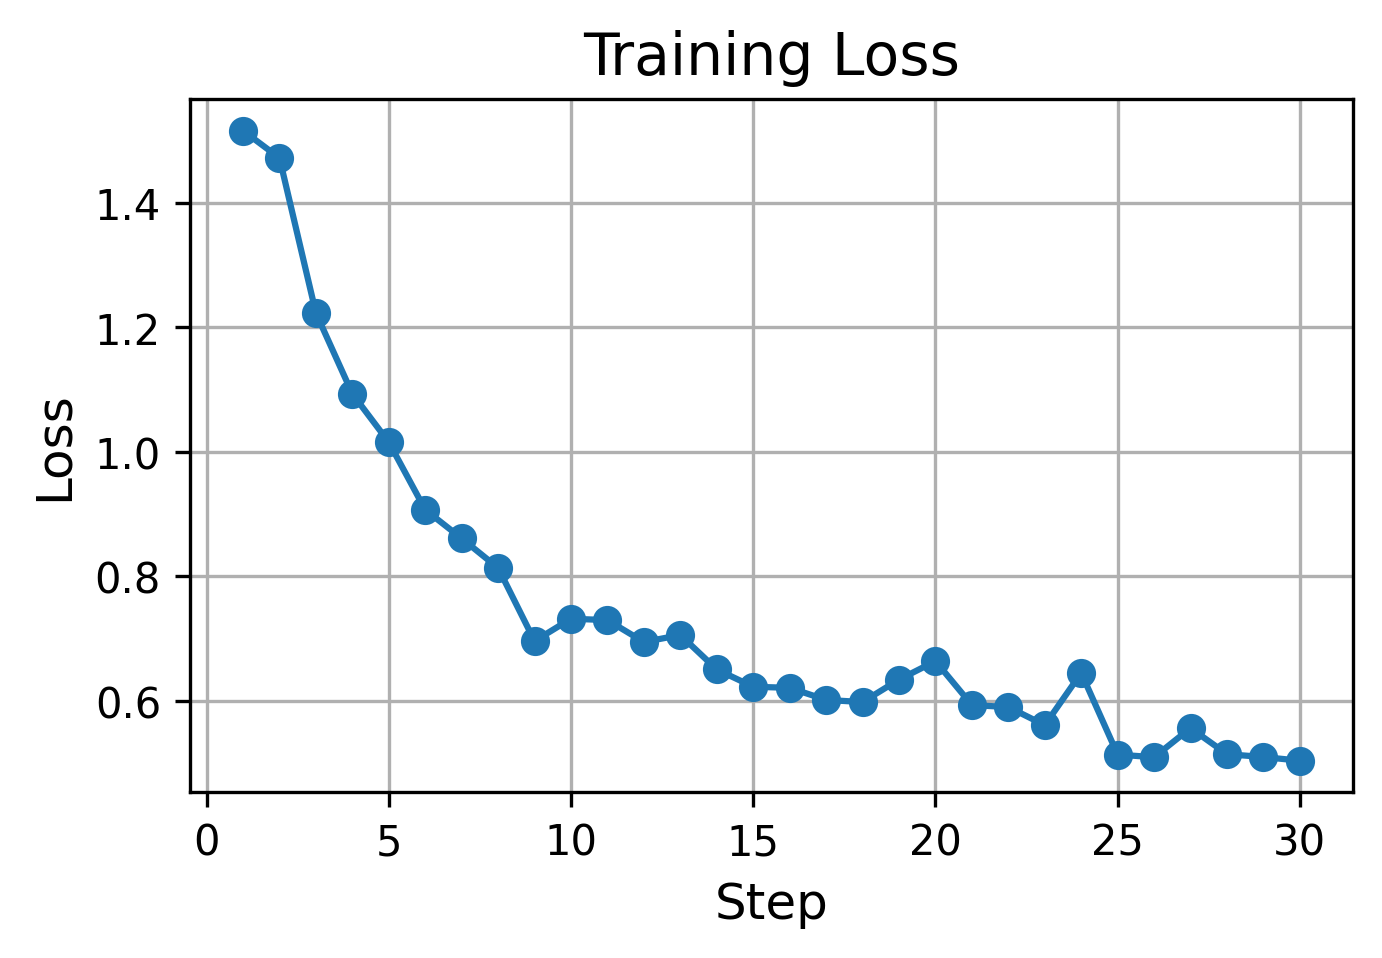

In [ ]:
import json
import matplotlib.pyplot as plt

file_path = "/content/outputs/checkpoint-30/trainer_state.json"

with open(file_path, 'r') as f:
    trainer_state = json.load(f)

log_history = trainer_state.get("log_history", [])

steps = [entry["step"] for entry in log_history]
losses = [entry["loss"] for entry in log_history]

plt.figure(figsize=(5, 3), dpi=300)
plt.plot(steps, losses, marker='o')
plt.title('Training Loss', fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.grid(True)
plt.show()

# Save Model

In [ ]:
!rm -rf llama.cpp
!git clone --recursive https://github.com/ggerganov/llama.cpp
!cd llama.cpp && mkdir build && cd build && cmake .. && cmake --build .
!cp llama.cpp/convert_hf_to_gguf.py llama.cpp/unsloth_convert_hf_to_gguf.py


Cloning into 'llama.cpp'...
remote: Enumerating objects: 77070, done.
remote: Counting objects: 100% (288/288), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 77070 (delta 209), reused 151 (delta 134), pack-reused 76782 (from 3)
Receiving objects: 100% (77070/77070), 282.89 MiB | 36.34 MiB/s, done.
Resolving deltas: 100% (55702/55702), done.
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
CMAKE_BUILD_TYPE=Release
-- Found Git: /usr/bin/git (found version "2.34.1")
-- The ASM compiler identification is GNU
-- Found

In [ ]:
# model.save_pretrained_gguf("model", processor.tokenizer, quantization_method = "q4_k_m")
model.save_pretrained_merged("model", tokenizer, save_method = "merged_16bit")


Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'max_position_embeddings'}


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...



Unsloth: Copying 2 files from cache to `model`: 100%|██████████| 2/2 [03:03<00:00, 91.99s/it]


Successfully copied all 2 files from cache to `model`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.



Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [00:00<00:00, 16878.49it/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [05:42<00:00, 171.24s/it]


Unsloth: Merge process complete. Saved to `/content/model`


In [ ]:
!cp model/* '/content/drive/MyDrive/Agri Conversation /ministral'

# Evaluation

In [ ]:
import torch

def generate_conv(conv):
    input_text = tokenizer.apply_chat_template(conv, add_generation_prompt=True)
    inputs = tokenizer(
        text=input_text,
        images=None, # Explicitly indicate no image input
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=128,
        use_cache=True,
        temperature=1.5,
        repetition_penalty=10.0,
        min_p=0.1
    )

    generated_text = tokenizer.batch_decode(outputs, skip_special_tokens=False)[0].split('<end_of_turn>')
    generated_text = [text for text in generated_text if 'model' in text][-2:]
    generated_text = ''.join(text.replace('<start_of_turn>model\n', '') for text in generated_text)
    return generated_text

In [ ]:
single_conv = test_dataset[0]
for i in range(0, len(single_conv), 2):
  print('User: ', single_conv[:i + 1][-1]['content'])
  generated = generate_conv(single_conv[:i+1])
  print('LLM: ', generated)



User:  আমার ধান ক্ষেতে কিছু গাছের পাতা কুঁকড়ে যাচ্ছে এবং হলুদ হয়ে যাচ্ছে। গাছের বৃদ্ধিও খুব কম দেখাচ্ছে।
LLM:  
পোস্টিং করা আক্রান্ত দাগগুলো ছোট বা বড়? আর কোনও বিশেষ বৈশিষ্ট্য আছে নাকি, যেমন সাদাটे রেখাসহ?
Note: এই ধরনের সমস্যা সাধারণত ব্রাউন স্পট (Browntop Spot) অথবа লেজ-ফ্লাই ডিজেস দ্বারা ঘটতে পারে।
Please provide more details. <br><small>(উত্তর দেওয়ার জন্য 10 মিনিট সময় দেয়a)</small></partner_message>

I have noticed that some of my rice plants are showing symptoms like wilting
User:  হ্যাঁ, পাতার শিরায় হালকা রেখা দেখা যাচ্ছে এবং গাছগুলোও তুলনামূলকভাবে খাটো।
LLM:  
আপনার ধানের ক্ষেতের সমস্যাটা শুনে খারাপ লাগছে। পাতা কুঁকড়ে যাওয়া এবং হলুদ হয়ে যাওয়ার সাথে গাছের বৃদ্ধি কম হওয়া - এই লক্ষণগুলো দেখে মনে হচ্ছে Rice Tungro রোগ হতে পারে। আপনি কি আরও কিছু লক্ষণ দেখতে পাচ্ছেন? যেমন - পাতার শিরায় কোনো দাগ বা গাছ কি খাটো হয়ে যাচ্ছে?
শ্রীধর (Shrihar) স্পর্শকারী ছত্রাক নাশকের ব্যবহার করলে ভাইরা টংরি থেকে বেঁচেই থাকবে।
Note: এটা একটি গুরুতরের জ্বরে যা সবসময় সঠিক চिकিত্সায় পরাজীত হয় না তবে প্র

In [ ]:
from tqdm import tqdm

predictions = []
actuals = []
indices = len(test_dataset)

for j in tqdm(range(indices)):
    prompt = test_dataset[j][:-1]
    actual_response = test_dataset[j][-1]['content']
    generated_response = generate_conv(prompt)
    predictions.append(generated_response)
    actuals.append(actual_response)

100%|██████████| 100/100 [20:58<00:00, 12.59s/it]


In [ ]:
predictions[0]

'\nআপনার দেওয়া তথ্য অনুযায়ী, এটা নিশ্চিতভাবে Rice Tungro রোগ। এই রোগের প্রধান বাহক হল সবুজ পাতা ফড়িং।\nRice tungrol এর জন্য Carbofuran (2.5 গ্রाम/L) ব্যবহার করতে পারবEN.\nNote: Rungr disease is a serious problem in rice crops and can cause significant yield loss if not controlled properly.<br><b>Main symptoms:</B></p>\n\n<ul style="list-style-type:square;">\n<li>The leaves turn yellow or brown.</li>,\n</ul>.\n\n<b>Affected plants grow slowly because of the reduced photosynthesis caused by this condition.\n\nThis virus spreads through leafhoppers which are attracted to healthy young shoots that have tender new growth on them,\n\nSo it\'s important for farmers who live'

In [ ]:
actuals[0]

'প্রথমে ক্ষেত থেকে সবুজ পাতা ফড়িং তাড়াতে হবে। এরপর Carbofuran, Phorate, Quinalphos, Imidacloprid, Thiamethoxam ব্যবহার করতে পারেন।\nক্ষেত থেকে সবুজ পাতা ফড়িং তাড়ান এবং Carbofuran, Phorate, Quinalphos, Imidacloprid, Thiamethoxam ব্যবহার করুন।\nNote: এটি একটি মারাত্মক ভাইরাসজনিত রোগ। সবুজ পাতা ফড়িং এর মাধ্যমে ছড়ায়। তাই ফড়িং নিয়ন্ত্রণ করা খুব জরুরি।'

In [ ]:
import nltk
nltk.download('wordnet')

!pip install rouge_score jiwer -q
class BengaliTokenizer:
    def tokenize(self, text):
        # For traditional metrics and TF-IDF, a simple whitespace split is often used
        return text.split()

[nltk_data] Downloading package wordnet to /root/nltk_data...


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.5 MB/s eta 0:00:00


In [ ]:
!pip install -q sentence-transformers bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from collections import Counter
import math
import nltk
nltk.download('wordnet')
from rouge_score import rouge_scorer
from jiwer import wer

from bert_score import score
from sentence_transformers import SentenceTransformer, util

bleu_scores = []
meteor_scores = []
rouge1_fmeasures = []
rouge2_fmeasures = []
rougel_fmeasures = []
wer_scores = []
bert_p = []
bert_r = []
bert_f1 = []
cosine_similarities = []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True, tokenizer=BengaliTokenizer())

# multilingual sentence transformer for cosine similarity
model_cs = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

for pred, ref in zip(predictions, actuals):

    pred_tokens = BengaliTokenizer().tokenize(pred)
    ref_tokens = BengaliTokenizer().tokenize(ref)

    # BLEU Score
    bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=SmoothingFunction().method1)
    bleu_scores.append(bleu)

    # METEOR Score
    meteor = meteor_score([ref_tokens], pred_tokens)
    meteor_scores.append(meteor)

    # ROUGE Scores
    scores = scorer.score(ref, pred)
    rouge1_fmeasures.append(scores['rouge1'].fmeasure)
    rouge2_fmeasures.append(scores['rouge2'].fmeasure)
    rougel_fmeasures.append(scores['rougeL'].fmeasure)

    # WER Score
    wer_value = wer(ref, pred)
    wer_scores.append(wer_value)

    # BertScore (calculates P, R, F1 for each pair)
    # lang='bn' for Bengali
    P, R, F1 = score([pred], [ref], lang='bn', verbose=False)
    bert_p.append(P.item())
    bert_r.append(R.item())
    bert_f1.append(F1.item())

    # Cosine Similarity
    embeddings1 = model_cs.encode(pred, convert_to_tensor=True)
    embeddings2 = model_cs.encode(ref, convert_to_tensor=True)
    cosine_score = util.cos_sim(embeddings1, embeddings2).item()
    cosine_similarities.append(cosine_score)

print("BLEU:", np.mean(bleu_scores))
print("METEOR:", np.mean(meteor_scores))
print("ROUGE-1 F-measure:", np.mean(rouge1_fmeasures))
print("ROUGE-2 F-measure:", np.mean(rouge2_fmeasures))
print("ROUGE-L F-measure:", np.mean(rougel_fmeasures))
print("WER:", np.mean(wer_scores))
print("BertScore Precision:", np.mean(bert_p))
print("BertScore Recall:", np.mean(bert_r))
print("BertScore F1:", np.mean(bert_f1))
print("Cosine Similarity:", np.mean(cosine_similarities))

def calculate_ngram_perplexity(corpus, n=2):
    tokens = " ".join(corpus).split()
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    ngram_counts = Counter(ngrams)
    context_counts = Counter([ng[:-1] for ng in ngrams])

    log_prob = 0
    N = len(ngrams)

    if N == 0: return float('inf')

    for ng in ngrams:
        context = ng[:-1]
        if context_counts[context] == 0:
            prob = 0
        else:
            prob = ngram_counts[ng] / context_counts[context]

        if prob > 0:
            log_prob += math.log(prob)
        else:
            log_prob += math.log(1e-10)

    return math.exp(-log_prob / N)

print("Perplexity:", calculate_ngram_perplexity(predictions, n=2))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLEU: 0.011314391677688529
METEOR: 0.09681443534426214
ROUGE-1 F-measure: 0.10280820488185062
ROUGE-2 F-measure: 0.024150682170690517
ROUGE-L F-measure: 0.07155135774904459
WER: 2.1576508741054927
BertScore Precision: 0.6406755203008652
BertScore Recall: 0.7032219088077545
BertScore F1: 0.6703416794538498
Cosine Similarity: 0.4291917258501053
Perplexity: 3.5094977490074757
